# 05 — Method 1: Hazard × Vulnerability Decision Support

Notebook ini menjalankan **Metode 1** sebagai final decision-support layer.

**Pertanyaan utama:**

> Saat skenario risiko banjir meningkat, actor-region mana yang harus diprioritaskan untuk intervensi rantai pasok beras?

Notebook 05 menggabungkan tiga hasil:

1. **Flood hazard** dari Notebook 03.
2. **Rice vulnerability** dari Notebook 03, yang targetnya berasal dari Method 3.
3. **Stress survival** dari Notebook 04 / Method 5.

## Domain basis

Metode ini mengikuti logika disaster risk:

```text
Risk = interaction of hazard, exposure, vulnerability, and capacity
```

Karena kedua dataset tidak punya key lokasi/waktu yang sama, integrasi dilakukan sebagai **scenario-based decision support**, bukan observasi kausal atau prediksi lokasi aktual.

## References used in the methodological notes

- UNDRR / UNISDR terminology: disaster risk emerges from the interaction of hazards with exposure, vulnerability, and capacity.
- IPCC risk framing: risk is shaped by hazard, exposure, and vulnerability.
- Ponomarov & Holcomb (2009): supply chain resilience.
- Wieland & Durach (2021): supply chain resilience as capacity to persist, adapt, or transform.

In [1]:
from pathlib import Path
import json, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
for p in [OUTPUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'legend.frameon': False
})
COLORS = {
    'blue': '#2F80ED',
    'navy': '#243B53',
    'orange': '#F2994A',
    'red': '#D64545',
    'green': '#27AE60',
    'purple': '#7B61FF',
    'gray': '#6B7280',
    'teal': '#2D9CDB'
}

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print('saved:', path)

def mode_or_unknown(s):
    s = s.dropna()
    if s.empty:
        return 'Unknown'
    return s.value_counts().idxmax()

## 1. Load outputs from Notebook 03 and Notebook 04

In [2]:
required = [
    '03_actor_region_model_summary.csv',
    '03_flood_scenario_summary.csv',
    '04_actor_region_stress_summary.csv',
    '04_stress_scenarios.csv'
]
missing = [f for f in required if not (OUTPUT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Jalankan Notebook 03 dan 04 dulu. Missing: {missing}')

actor_region = pd.read_csv(OUTPUT_DIR / '03_actor_region_model_summary.csv')
flood_scenarios = pd.read_csv(OUTPUT_DIR / '04_stress_scenarios.csv')
stress_summary = pd.read_csv(OUTPUT_DIR / '04_actor_region_stress_summary.csv')

print('Actor-region:', actor_region.shape)
print('Flood scenarios:', flood_scenarios.shape)
print('Stress summary:', stress_summary.shape)
display(actor_region.head(3))
display(flood_scenarios)
display(stress_summary.head(3))

Actor-region: (24, 15)
Flood scenarios: (3, 7)
Stress summary: (72, 12)


,region,actor,n_units,median_total_cost,median_revenue,median_margin,median_cost_revenue_ratio,median_operational_burden_ratio,median_margin_ratio,median_vulnerability_score,dominant_true_vulnerability_label,dominant_predicted_vulnerability_label,predicted_high_vulnerability_share,true_high_vulnerability_share,median_predicted_proba_high
0,Garut,Farmer,98,7641100.0,13570000.0,6111000.0,0.417240,0.224878,0.582760,0.251364,Low Vulnerability,Low Vulnerability,0.204082,0.214286,0.0
1,Garut,Middlemen,24,40650000.0,26840000.0,-6500000.0,1.357774,0.278229,-0.357774,0.705973,High Vulnerability,High Vulnerability,0.916667,0.916667,1.0
2,Garut,Retail,23,5750000.0,3500000.0,-2600000.0,1.742857,1.000000,-0.742857,0.763876,High Vulnerability,High Vulnerability,0.913043,0.913043,1.0


,flood_scenario,cost_shock_pct,scenario_interpretation,n_flood_cases,flood_probability_reference,flood_probability_min,flood_probability_max
0,Low,0.05,low cost-side stress grid,16667,0.450002,0.285010,0.475001
1,Medium,0.15,medium cost-side stress grid,16666,0.500000,0.475001,0.519999
2,High,0.30,high cost-side stress grid,16667,0.549998,0.519999,0.724990


,flood_scenario,region,actor,n_units,fail_share,survive_share,median_stressed_margin,median_stressed_cost_revenue_ratio,median_combined_buffer,dominant_stress_risk_label,dominant_predicted_vulnerability_label,stress_priority_signal
0,High,Garut,Farmer,98,0.295918,0.704082,4932000.0,0.542412,0.582760,Survives Scenario,Low Vulnerability,Watch
1,High,Garut,Middlemen,24,1.000000,0.000000,-24497500.0,1.765106,-0.357774,Already Failed,High Vulnerability,Severe
2,High,Garut,Retail,23,1.000000,0.000000,-4392500.0,2.265714,-0.742857,Already Failed,High Vulnerability,Severe


## 2. Decision policy

Output final menggunakan **rule-based priority matrix**, bukan supervised model baru.

Alasan:

- `priority_label` adalah hasil keputusan dari `hazard × vulnerability × stress`, bukan ground-truth observasi.
- Jika dilatih sebagai supervised target baru, model hanya akan meniru rule yang kita buat sendiri.
- Rule matrix lebih transparan untuk stakeholder kebijakan.

## Label logic

| Condition | Priority |
|---|---|
| High flood + High vulnerability | Critical |
| High/Medium flood + high stress fail share | Critical |
| High flood + Medium vulnerability | High |
| Medium flood + High vulnerability | High |
| Low flood + High vulnerability | Watchlist |
| Low vulnerability + low stress | Routine |

In [3]:
vulnerability_rank = {
    'Low Vulnerability': 1,
    'Medium Vulnerability': 2,
    'High Vulnerability': 3
}
flood_rank = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

# Use actor-region vulnerability summary from Notebook 03.
base = actor_region.copy()
base['vulnerability_label'] = base['dominant_predicted_vulnerability_label']
base['vulnerability_rank'] = base['vulnerability_label'].map(vulnerability_rank).fillna(2).astype(int)

# Merge stress result by scenario + actor + region.
decision = stress_summary.merge(
    base[
        [
            'region', 'actor', 'n_units',
            'vulnerability_label', 'vulnerability_rank',
            'predicted_high_vulnerability_share',
            'median_cost_revenue_ratio',
            'median_margin',
        ]
        + ([c for c in ['median_vulnerability_score', 'median_predicted_proba_high'] if c in base.columns])
    ],
    on=['region', 'actor'],
    how='left',
    suffixes=('', '_from_model')
)

# Add flood scenario probability reference.
decision = decision.merge(
    flood_scenarios[['flood_scenario', 'flood_probability_reference', 'cost_shock_pct']],
    on='flood_scenario',
    how='left',
    suffixes=('', '_scenario')
)
decision['flood_rank'] = decision['flood_scenario'].map(flood_rank).fillna(2).astype(int)

def assign_priority(row):
    flood = row['flood_rank']
    vuln = row['vulnerability_rank']
    fail_share = row['fail_share']

    if flood == 3 and vuln == 3:
        return 'Critical'
    if flood >= 2 and fail_share >= 0.75:
        return 'Critical'
    if flood == 3 and fail_share >= 0.50:
        return 'Critical'
    if flood == 3 and vuln == 2:
        return 'High'
    if flood == 2 and vuln == 3:
        return 'High'
    if fail_share >= 0.50:
        return 'High'
    if vuln == 3:
        return 'Watchlist'
    if flood == 3 and vuln == 1:
        return 'Moderate'
    if fail_share >= 0.25:
        return 'Moderate'
    return 'Routine'

decision['priority_label'] = decision.apply(assign_priority, axis=1)

priority_rank = {'Routine': 1, 'Moderate': 2, 'Watchlist': 3, 'High': 4, 'Critical': 5}
decision['priority_rank'] = decision['priority_label'].map(priority_rank)

# Keep a score for sorting only, not as a trained target.
decision['priority_sort_score'] = (
    0.45 * (decision['vulnerability_rank'] / 3)
    + 0.35 * (decision['flood_rank'] / 3)
    + 0.20 * decision['fail_share'].fillna(0)
)
display(decision.head())

,flood_scenario,region,actor,n_units,fail_share,survive_share,median_stressed_margin,median_stressed_cost_revenue_ratio,median_combined_buffer,dominant_stress_risk_label,dominant_predicted_vulnerability_label,stress_priority_signal,n_units_from_model,vulnerability_label,vulnerability_rank,predicted_high_vulnerability_share,median_cost_revenue_ratio,median_margin,median_vulnerability_score,median_predicted_proba_high,flood_probability_reference,cost_shock_pct,flood_rank,priority_label,priority_rank,priority_sort_score
0,High,Garut,Farmer,98,0.295918,0.704082,4.932000e+06,0.542412,0.582760,Survives Scenario,Low Vulnerability,Watch,98,Low Vulnerability,1,0.204082,0.417240,6.111000e+06,0.251364,0.0,0.549998,0.3,3,Moderate,2,0.559184
1,High,Garut,Middlemen,24,1.000000,0.000000,-2.449750e+07,1.765106,-0.357774,Already Failed,High Vulnerability,Severe,24,High Vulnerability,3,0.916667,1.357774,-6.500000e+06,0.705973,1.0,0.549998,0.3,3,Critical,5,1.000000
2,High,Garut,Retail,23,1.000000,0.000000,-4.392500e+06,2.265714,-0.742857,Already Failed,High Vulnerability,Severe,23,High Vulnerability,3,0.913043,1.742857,-2.600000e+06,0.763876,1.0,0.549998,0.3,3,Critical,5,1.000000
3,High,Garut,Rice Miller,24,0.666667,0.333333,-5.242662e+06,1.084591,0.165699,Already Failed,Low Vulnerability,High,24,Low Vulnerability,1,0.416667,0.834301,1.070069e+07,0.290517,0.0,0.549998,0.3,3,Critical,5,0.633333
4,High,Garut,Wholesaler,25,0.920000,0.080000,-2.726000e+07,1.403409,-0.079545,Already Failed,High Vulnerability,Severe,25,High Vulnerability,3,0.720000,1.079545,-7.000000e+06,0.746619,1.0,0.549998,0.3,3,Critical,5,0.984000


## 3. Recommended action per actor and priority

In [4]:
def recommended_action(row):
    actor = str(row['actor'])
    priority = row['priority_label']
    fail_share = row['fail_share']
    cr = row.get('median_cost_revenue_ratio', np.nan)

    if priority == 'Critical':
        if actor == 'Farmer':
            return 'Prioritize input-cost support, harvest protection, and post-flood production monitoring.'
        if actor == 'Rice Miller':
            return 'Secure milling capacity, backup machine schedule, and protect grain-to-rice processing continuity.'
        if actor == 'Middlemen':
            return 'Monitor distribution bottleneck, prepare alternative storage, and coordinate pickup/delivery windows.'
        if actor == 'Wholesaler':
            return 'Prepare buffer stock and route contingency for bulk distribution.'
        if actor == 'Retail':
            return 'Prepare buffer stock, backup suppliers, and consumer price monitoring.'
        return 'Immediate monitoring and continuity support.'
    if priority == 'High':
        if fail_share >= 0.50:
            return 'Prepare contingency plan because many units fail under stress scenario.'
        return 'Increase monitoring frequency and prepare targeted operational support.'
    if priority == 'Watchlist':
        return 'Watch financial feasibility and margin because vulnerability is high even when flood scenario is not high.'
    if priority == 'Moderate':
        return 'Monitor periodically and prepare support if flood-risk scenario escalates.'
    return 'Routine monitoring.'

decision['recommended_action'] = decision.apply(recommended_action, axis=1)

# Reason text.
def priority_reason(row):
    parts = [
        f"Flood={row['flood_scenario']}",
        f"Vulnerability={row['vulnerability_label']}",
        f"FailShare={row['fail_share']:.0%}"
    ]
    if pd.notna(row.get('median_cost_revenue_ratio')):
        parts.append(f"Median C/R={row['median_cost_revenue_ratio']:.2f}")
    return '; '.join(parts)

decision['priority_reason'] = decision.apply(priority_reason, axis=1)

cols = [
    'region', 'actor', 'flood_scenario', 'flood_probability_reference',
    'vulnerability_label', 'predicted_high_vulnerability_share',
    'fail_share', 'survive_share',
    'dominant_stress_risk_label',
    'median_margin', 'median_cost_revenue_ratio',
    'median_stressed_margin', 'median_stressed_cost_revenue_ratio',
    'priority_label', 'priority_rank', 'priority_sort_score',
    'priority_reason', 'recommended_action'
]
cols = [c for c in cols if c in decision.columns]
final_priority = decision[cols].sort_values(['priority_rank', 'priority_sort_score'], ascending=[False, False]).reset_index(drop=True)

final_priority.to_csv(OUTPUT_DIR / '05_final_flood_logistics_priority.csv', index=False)
display(final_priority.head(15))

,region,actor,flood_scenario,flood_probability_reference,vulnerability_label,predicted_high_vulnerability_share,fail_share,survive_share,dominant_stress_risk_label,median_margin,median_cost_revenue_ratio,median_stressed_margin,median_stressed_cost_revenue_ratio,priority_label,priority_rank,priority_sort_score,priority_reason,recommended_action
0,Garut,Middlemen,High,0.549998,High Vulnerability,0.916667,1.000000,0.000000,Already Failed,-6.500000e+06,1.357774,-2.449750e+07,1.765106,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
1,Garut,Retail,High,0.549998,High Vulnerability,0.913043,1.000000,0.000000,Already Failed,-2.600000e+06,1.742857,-4.392500e+06,2.265714,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
2,Indramayu,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.051000e+06,2.114500,-4.694550e+06,2.748850,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
3,Karawang,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.070000e+06,2.023333,-4.826000e+06,2.630333,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
4,Karawang,Rice Miller,High,0.549998,High Vulnerability,0.714286,1.000000,0.000000,Already Failed,-5.688835e+06,1.064403,-3.223887e+07,1.383724,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Secure milling capacity, backup machine schedu..."
5,Subang,Retail,High,0.549998,High Vulnerability,0.947368,1.000000,0.000000,Already Failed,-2.495000e+06,1.733333,-4.150000e+06,2.253333,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
6,Tasikmalaya,Middlemen,High,0.549998,High Vulnerability,0.793103,1.000000,0.000000,Already Failed,-7.685347e+06,1.296086,-2.090750e+07,1.684912,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
7,Tasikmalaya,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.053750e+06,2.017917,-4.869875e+06,2.623292,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
8,Garut,Wholesaler,High,0.549998,High Vulnerability,0.720000,0.920000,0.080000,Already Failed,-7.000000e+06,1.079545,-2.726000e+07,1.403409,Critical,5,0.984000,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
9,Subang,Middlemen,High,0.549998,High Vulnerability,0.428571,0.857143,0.142857,Already Failed,1.484000e+07,0.922399,-1.978000e+07,1.199119,Critical,5,0.971429,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."


## 4. High-priority shortlist

In [5]:
shortlist = final_priority[final_priority['priority_label'].isin(['Critical', 'High'])].copy()
shortlist.to_csv(OUTPUT_DIR / '05_high_priority_shortlist.csv', index=False)

actions = (
    final_priority.groupby(['flood_scenario', 'priority_label', 'actor'], dropna=False)
    .agg(
        n_actor_region=('actor', 'size'),
        avg_fail_share=('fail_share', 'mean'),
        example_action=('recommended_action', mode_or_unknown)
    )
    .reset_index()
    .sort_values(['flood_scenario', 'priority_label', 'avg_fail_share'], ascending=[True, True, False])
)
actions.to_csv(OUTPUT_DIR / '05_actor_region_recommended_actions.csv', index=False)

print('Critical/High rows:', len(shortlist))
display(shortlist.head(20))
display(actions.head(20))

Critical/High rows: 44


,region,actor,flood_scenario,flood_probability_reference,vulnerability_label,predicted_high_vulnerability_share,fail_share,survive_share,dominant_stress_risk_label,median_margin,median_cost_revenue_ratio,median_stressed_margin,median_stressed_cost_revenue_ratio,priority_label,priority_rank,priority_sort_score,priority_reason,recommended_action
0,Garut,Middlemen,High,0.549998,High Vulnerability,0.916667,1.000000,0.000000,Already Failed,-6.500000e+06,1.357774,-2.449750e+07,1.765106,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
1,Garut,Retail,High,0.549998,High Vulnerability,0.913043,1.000000,0.000000,Already Failed,-2.600000e+06,1.742857,-4.392500e+06,2.265714,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
2,Indramayu,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.051000e+06,2.114500,-4.694550e+06,2.748850,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
3,Karawang,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.070000e+06,2.023333,-4.826000e+06,2.630333,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
4,Karawang,Rice Miller,High,0.549998,High Vulnerability,0.714286,1.000000,0.000000,Already Failed,-5.688835e+06,1.064403,-3.223887e+07,1.383724,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Secure milling capacity, backup machine schedu..."
5,Subang,Retail,High,0.549998,High Vulnerability,0.947368,1.000000,0.000000,Already Failed,-2.495000e+06,1.733333,-4.150000e+06,2.253333,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
6,Tasikmalaya,Middlemen,High,0.549998,High Vulnerability,0.793103,1.000000,0.000000,Already Failed,-7.685347e+06,1.296086,-2.090750e+07,1.684912,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
7,Tasikmalaya,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.053750e+06,2.017917,-4.869875e+06,2.623292,Critical,5,1.000000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
8,Garut,Wholesaler,High,0.549998,High Vulnerability,0.720000,0.920000,0.080000,Already Failed,-7.000000e+06,1.079545,-2.726000e+07,1.403409,Critical,5,0.984000,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
9,Subang,Middlemen,High,0.549998,High Vulnerability,0.428571,0.857143,0.142857,Already Failed,1.484000e+07,0.922399,-1.978000e+07,1.199119,Critical,5,0.971429,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."


,flood_scenario,priority_label,actor,n_actor_region,avg_fail_share,example_action
1,High,Critical,Retail,5,1.000000,"Prepare buffer stock, backup suppliers, and co..."
0,High,Critical,Middlemen,5,0.933929,"Monitor distribution bottleneck, prepare alter..."
2,High,Critical,Rice Miller,4,0.870014,"Secure milling capacity, backup machine schedu..."
3,High,Critical,Wholesaler,3,0.797738,Prepare buffer stock and route contingency for...
5,High,Moderate,Rice Miller,1,0.428571,Monitor periodically and prepare support if fl...
6,High,Moderate,Wholesaler,1,0.190476,Monitor periodically and prepare support if fl...
4,High,Moderate,Farmer,5,0.165484,Monitor periodically and prepare support if fl...
8,Low,High,Retail,5,0.991304,Prepare contingency plan because many units fa...
9,Low,High,Rice Miller,1,0.785714,Prepare contingency plan because many units fa...
7,Low,High,Middlemen,4,0.774861,Prepare contingency plan because many units fa...


## 5. Focused visualizations

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\05_priority_distribution_by_scenario.png


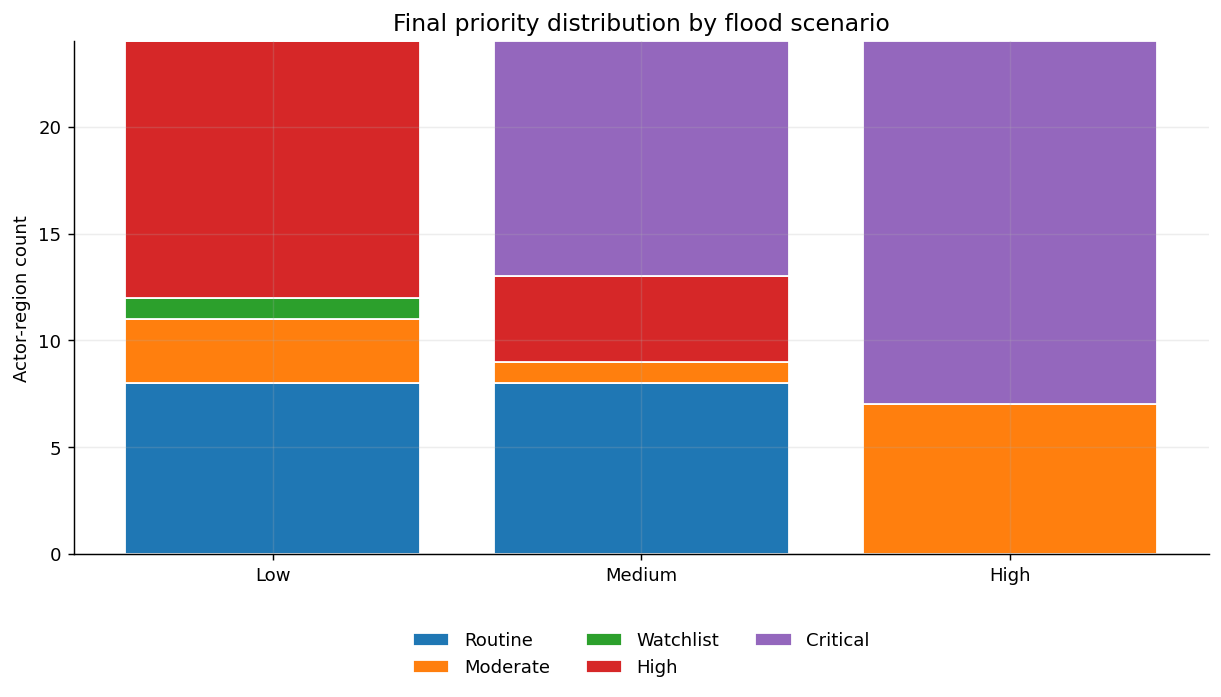

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\05_top_high_flood_priorities.png


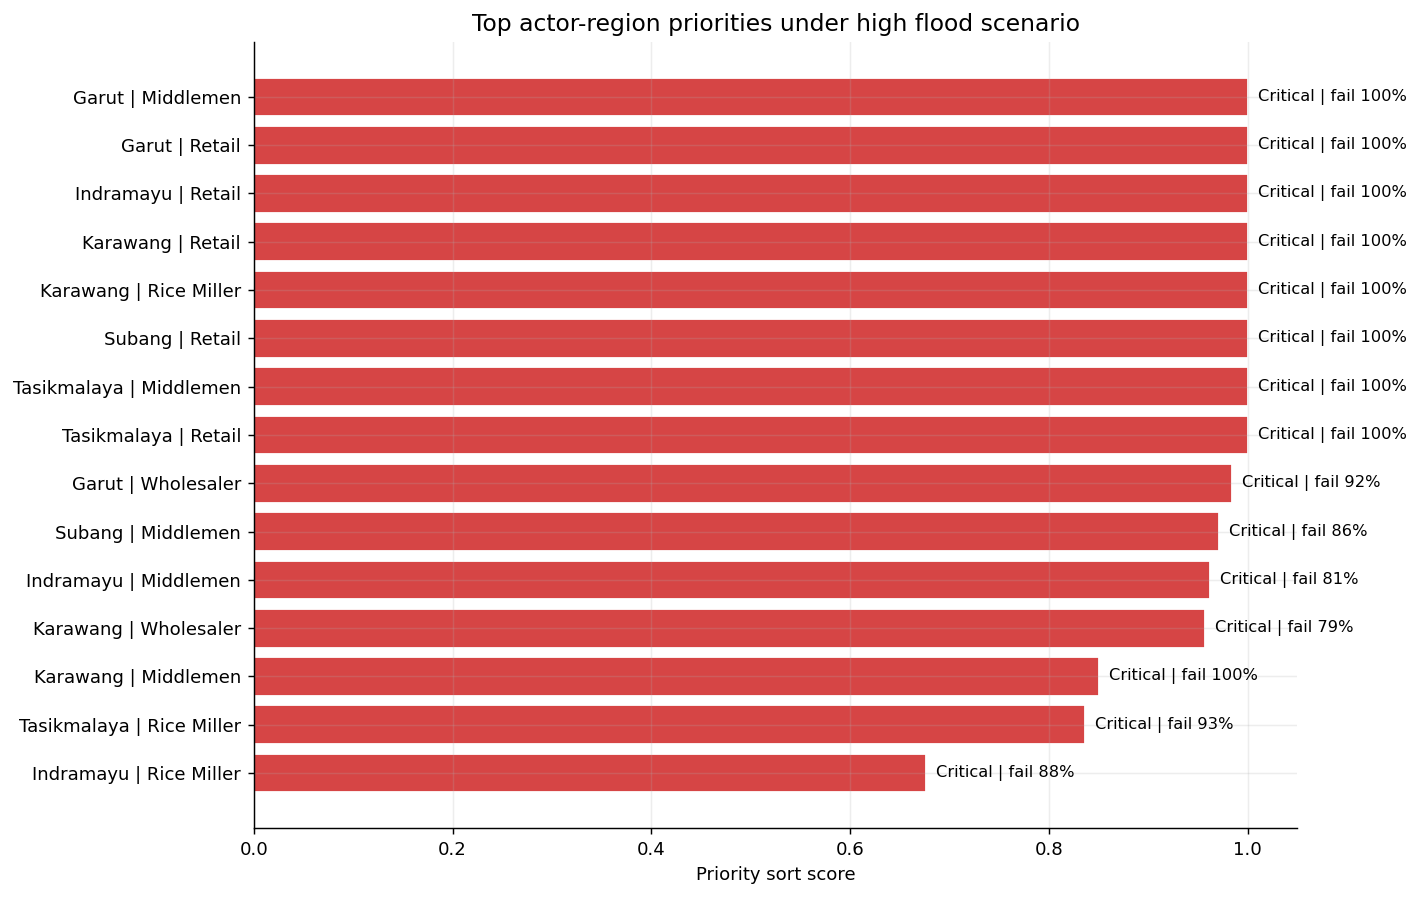

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\05_high_flood_critical_high_share_by_actor.png


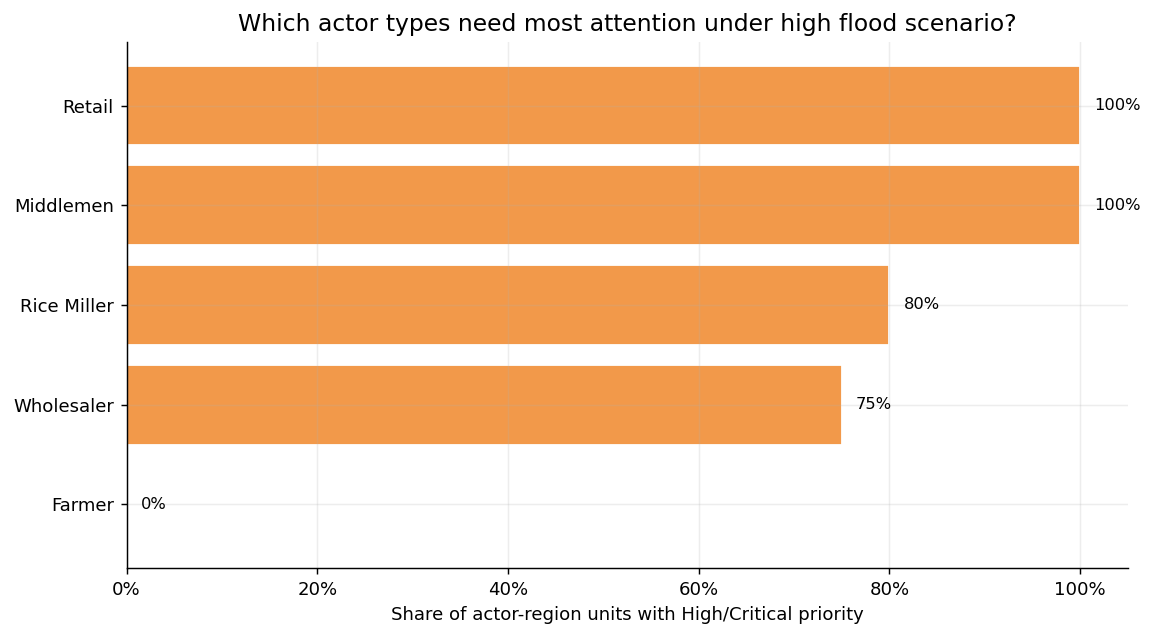

In [6]:
# Visualization 1: priority count by scenario.
priority_order = ['Routine', 'Moderate', 'Watchlist', 'High', 'Critical']
count_df = (
    final_priority.groupby(['flood_scenario', 'priority_label'])
    .size()
    .reset_index(name='count')
)
pivot = count_df.pivot(index='flood_scenario', columns='priority_label', values='count').reindex(index=['Low', 'Medium', 'High']).fillna(0)
pivot = pivot.reindex(columns=[c for c in priority_order if c in pivot.columns]).fillna(0)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bottom = np.zeros(len(pivot))
for col in pivot.columns:
    vals = pivot[col].values
    ax.bar(pivot.index, vals, bottom=bottom, label=col, edgecolor='white')
    bottom += vals
ax.set_ylabel('Actor-region count')
ax.set_title('Final priority distribution by flood scenario')
ax.legend(ncols=3, bbox_to_anchor=(0.5, -0.12), loc='upper center')
savefig('05_priority_distribution_by_scenario.png')
plt.show()

# Visualization 2: high scenario ranking.
high = final_priority[final_priority['flood_scenario'].eq('High')].copy()
top = high.sort_values(['priority_rank', 'priority_sort_score'], ascending=[False, False]).head(15)
fig, ax = plt.subplots(figsize=(11, 7))
labels = top['region'] + ' | ' + top['actor']
bars = ax.barh(labels[::-1], top['priority_sort_score'][::-1], color=COLORS['red'], edgecolor='white')
ax.set_xlabel('Priority sort score')
ax.set_title('Top actor-region priorities under high flood scenario')
for b, lab, fail in zip(bars, top['priority_label'][::-1], top['fail_share'][::-1]):
    ax.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2, f'{lab} | fail {fail:.0%}', va='center', fontsize=9)
savefig('05_top_high_flood_priorities.png')
plt.show()

# Visualization 3: critical/high share by actor under high scenario.
actor_priority = (
    high.assign(_critical_high=high['priority_label'].isin(['Critical', 'High']).astype(float))
    .groupby('actor')
    .agg(critical_high_share=('_critical_high', 'mean'), n_actor_region=('actor', 'size'))
    .reset_index()
    .sort_values('critical_high_share')
)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(actor_priority['actor'], actor_priority['critical_high_share'], color=COLORS['orange'], edgecolor='white')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Share of actor-region units with High/Critical priority')
ax.set_title('Which actor types need most attention under high flood scenario?')
for b, v in zip(bars, actor_priority['critical_high_share']):
    ax.text(v + 0.015, b.get_y() + b.get_height()/2, f'{v:.0%}', va='center', fontsize=9)
savefig('05_high_flood_critical_high_share_by_actor.png')
plt.show()

## 5B. Final decision diagnostics and stakeholder-facing summary

The final notebook should make the Method 1 decision layer transparent. The following outputs show the priority matrix, stakeholder action summary, and a presentation-ready top intervention shortlist.

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\05_priority_matrix_heatmap.png


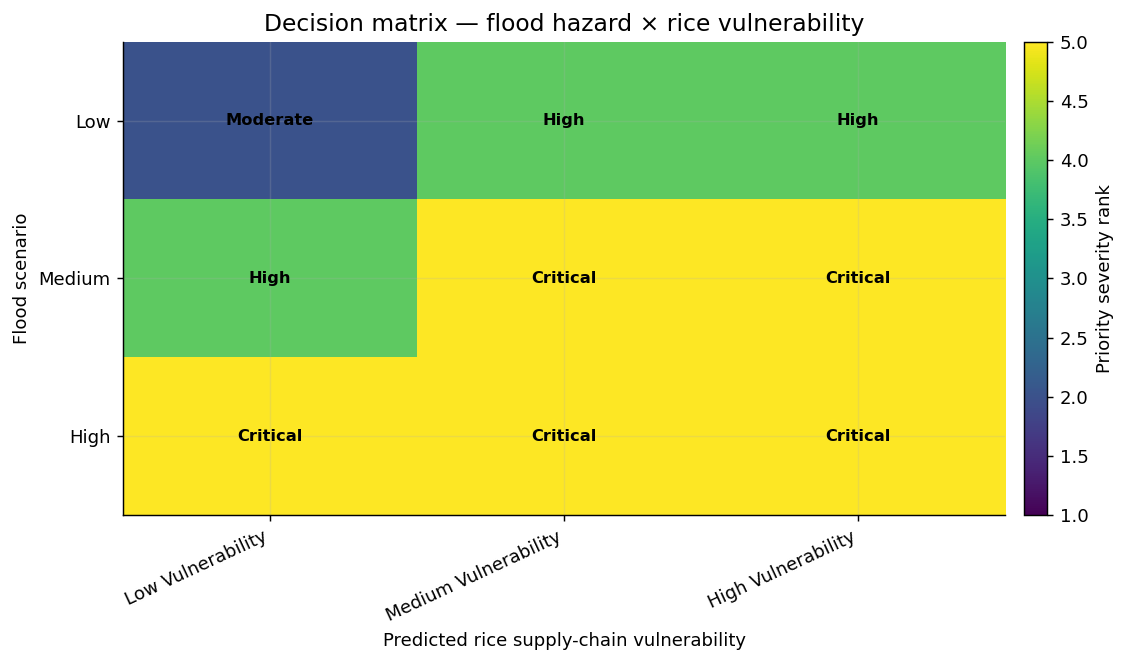

,region,actor,flood_scenario,vulnerability_label,fail_share,median_cost_revenue_ratio,median_stressed_margin,priority_label,priority_reason,recommended_action
2,Indramayu,Retail,High,High Vulnerability,1.000000,2.114500,-4.694550e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
3,Karawang,Retail,High,High Vulnerability,1.000000,2.023333,-4.826000e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
7,Tasikmalaya,Retail,High,High Vulnerability,1.000000,2.017917,-4.869875e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
1,Garut,Retail,High,High Vulnerability,1.000000,1.742857,-4.392500e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
5,Subang,Retail,High,High Vulnerability,1.000000,1.733333,-4.150000e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
0,Garut,Middlemen,High,High Vulnerability,1.000000,1.357774,-2.449750e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
6,Tasikmalaya,Middlemen,High,High Vulnerability,1.000000,1.296086,-2.090750e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
4,Karawang,Rice Miller,High,High Vulnerability,1.000000,1.064403,-3.223887e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Secure milling capacity, backup machine schedu..."
8,Garut,Wholesaler,High,High Vulnerability,0.920000,1.079545,-2.726000e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
9,Subang,Middlemen,High,High Vulnerability,0.857143,0.922399,-1.978000e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."


,stakeholder,action_focus,trigger,specific_use
0,Dinas Ketahanan Pangan,Prioritize buffer stock and supply continuity ...,"Priority label = Critical or High, especially ...",Identify which actor-region nodes need food av...
1,BPBD / disaster coordination team,Use flood scenario as logistics alert trigger ...,High flood scenario combined with High Vulnera...,Connect disaster preparedness with food logist...
2,Bulog / Bapanas or local food reserve managers,Prepare stock redistribution and backup supply...,High fail share or High/Critical priority amon...,Target limited reserve or distribution support...
3,Dinas Perdagangan,Monitor price pressure in downstream nodes wit...,Retail or wholesaler actor-region units with H...,Focus price monitoring on areas where retailer...
4,Supply-chain actors / cooperatives,Use actor-specific recommendations to prepare ...,Actor-region appears in top intervention short...,Translate risk score into operational actions ...


In [7]:
# Priority matrix heatmap: vulnerability × flood scenario.
priority_rank = {'Routine': 1, 'Moderate': 2, 'Watchlist': 3, 'High': 4, 'Critical': 5}
priority_rank_inv = {v: k for k, v in priority_rank.items()}

matrix = (
    final_priority.groupby(['flood_scenario', 'vulnerability_label'], dropna=False)
    .agg(max_priority_rank=('priority_rank', 'max'), n_actor_region=('actor', 'size'))
    .reset_index()
)
scenario_order = ['Low', 'Medium', 'High']
vuln_order = ['Low Vulnerability', 'Medium Vulnerability', 'High Vulnerability']
mat = matrix.pivot(index='flood_scenario', columns='vulnerability_label', values='max_priority_rank').reindex(index=scenario_order, columns=vuln_order)
mat.to_csv(OUTPUT_DIR / '05_priority_matrix_heatmap_values.csv')

fig, ax = plt.subplots(figsize=(8.8, 5.2))
im = ax.imshow(mat.fillna(0).values, aspect='auto', vmin=1, vmax=5)
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=25, ha='right')
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
ax.set_xlabel('Predicted rice supply-chain vulnerability')
ax.set_ylabel('Flood scenario')
ax.set_title('Decision matrix — flood hazard × rice vulnerability')
for i, scen in enumerate(mat.index):
    for j, vuln in enumerate(mat.columns):
        val = mat.loc[scen, vuln]
        if pd.notna(val) and val > 0:
            ax.text(j, i, priority_rank_inv.get(int(val), ''), ha='center', va='center', fontsize=9, fontweight='bold')
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Priority severity rank')
savefig('05_priority_matrix_heatmap.png')
plt.show()

# Final top 10 intervention priority table under high flood scenario.
top10 = (
    final_priority[final_priority['flood_scenario'].eq('High')]
    .sort_values(['priority_rank', 'priority_sort_score', 'fail_share', 'median_cost_revenue_ratio'], ascending=[False, False, False, False])
    .head(10)
    .copy()
)
top10_cols = [
    'region', 'actor', 'flood_scenario', 'vulnerability_label', 'fail_share',
    'median_cost_revenue_ratio', 'median_stressed_margin', 'priority_label',
    'priority_reason', 'recommended_action'
]
top10_cols = [c for c in top10_cols if c in top10.columns]
top10[top10_cols].to_csv(OUTPUT_DIR / '05_top10_intervention_priority.csv', index=False)
display(top10[top10_cols])

# Stakeholder-facing action summary.
stakeholder_actions = pd.DataFrame([
    {
        'stakeholder': 'Dinas Ketahanan Pangan',
        'action_focus': 'Prioritize buffer stock and supply continuity monitoring for Critical actor-region units.',
        'trigger': 'Priority label = Critical or High, especially under High flood scenario.',
        'specific_use': 'Identify which actor-region nodes need food availability monitoring before disruption escalates.'
    },
    {
        'stakeholder': 'BPBD / disaster coordination team',
        'action_focus': 'Use flood scenario as logistics alert trigger for vulnerable supply-chain nodes.',
        'trigger': 'High flood scenario combined with High Vulnerability or high fail share.',
        'specific_use': 'Connect disaster preparedness with food logistics risk rather than treating flood risk as a standalone hazard.'
    },
    {
        'stakeholder': 'Bulog / Bapanas or local food reserve managers',
        'action_focus': 'Prepare stock redistribution and backup supply for retail, wholesalers, and middlemen with Critical priority.',
        'trigger': 'High fail share or High/Critical priority among downstream actors.',
        'specific_use': 'Target limited reserve or distribution support to nodes most likely to disrupt consumer access.'
    },
    {
        'stakeholder': 'Dinas Perdagangan',
        'action_focus': 'Monitor price pressure in downstream nodes with weak margin and high cost/revenue ratio.',
        'trigger': 'Retail or wholesaler actor-region units with High Vulnerability and High/Critical priority.',
        'specific_use': 'Focus price monitoring on areas where retailer feasibility is already weak.'
    },
    {
        'stakeholder': 'Supply-chain actors / cooperatives',
        'action_focus': 'Use actor-specific recommendations to prepare backup suppliers, storage, or processing capacity.',
        'trigger': 'Actor-region appears in top intervention shortlist.',
        'specific_use': 'Translate risk score into operational actions at farmer, miller, middleman, wholesaler, and retail levels.'
    },
])
stakeholder_actions.to_csv(OUTPUT_DIR / '05_stakeholder_action_summary.csv', index=False)
display(stakeholder_actions)

## 6. Export methodological notes and decision policy

In [8]:
policy = pd.DataFrame([
    {
        'decision': 'Use hazard × vulnerability as final decision layer',
        'domain_basis': 'Disaster risk is understood through interaction of hazard, exposure, vulnerability, and capacity.',
        'reference': 'UNDRR/UNISDR terminology; IPCC risk framing'
    },
    {
        'decision': 'Do not train new supervised priority model',
        'domain_basis': 'Priority label is a decision rule output, not observed ground truth.',
        'reference': 'Model governance / pseudo-label limitation'
    },
    {
        'decision': 'Critical if high flood and high vulnerability',
        'domain_basis': 'A high hazard scenario interacting with highly vulnerable supply-chain units creates highest intervention need.',
        'reference': 'Hazard-vulnerability risk framework'
    },
    {
        'decision': 'Use stress fail share as capacity/resilience signal',
        'domain_basis': 'Resilience concerns ability to persist/adapt under disruption; failure under stress indicates low buffer.',
        'reference': 'Ponomarov & Holcomb (2009); Wieland & Durach (2021)'
    },
    {
        'decision': 'Actor-specific recommended actions',
        'domain_basis': 'Different rice supply-chain actors represent different operational roles: production, milling, intermediation, wholesale, and retail access.',
        'reference': 'Rice supply chain structure from provided dataset'
    }
])
policy.to_csv(OUTPUT_DIR / '05_decision_policy_reference.csv', index=False)

notes = '''# Method 1 Notes — Hazard × Vulnerability Decision Support

This notebook is a decision-support layer, not a new supervised model.

## Why no new model?

The final priority label is not observed ground truth. It is a policy-style decision layer built from:

1. predicted flood hazard scenario,
2. predicted rice supply-chain vulnerability, and
3. stress-test survival / fail-share from Method 5.

Training another model to predict this label would only replicate the rule matrix and make the process less transparent.

## Domain grounding

The decision framework follows disaster-risk logic: risk emerges from the interaction of hazard with exposure, vulnerability, and capacity. In this project:

- flood scenario = hazard,
- rice actor-region unit = exposed supply-chain node,
- vulnerability label = financial/operational vulnerability,
- stress fail share = low resilience / low buffer,
- priority label = intervention priority.

## Limitation

Because the flood and rice datasets do not share a common geographic or temporal key, this notebook does not claim actual flood impact prediction for a specific district/date. It is a scenario-based risk-prioritization framework.
'''
(OUTPUT_DIR / '05_method1_notes.md').write_text(notes, encoding='utf-8')

manifest = {
    'final_output': '05_final_flood_logistics_priority.csv',
    'shortlist_output': '05_high_priority_shortlist.csv',
    'recommended_action_output': '05_actor_region_recommended_actions.csv',
    'scope': 'scenario-based decision support',
    'not_a_claim': 'not actual location-specific flood impact prediction',
    'input_notebooks': ['03_model_training_evaluation', '04_flood_stress_test_sensitivity_analysis'],
}
json.dump(manifest, open(OUTPUT_DIR / '05_decision_support_manifest.json', 'w'), indent=2)

print('Saved Method 1 outputs:')
for p in sorted(OUTPUT_DIR.glob('05_*')):
    print('-', p.name)

Saved Method 1 outputs:
- 05_actor_region_recommended_actions.csv
- 05_decision_policy_reference.csv
- 05_decision_support_manifest.json
- 05_final_flood_logistics_priority.csv
- 05_high_priority_shortlist.csv
- 05_method1_notes.md
- 05_priority_matrix_heatmap_values.csv
- 05_stakeholder_action_summary.csv
- 05_top10_intervention_priority.csv
